# Exploratory Data Analysis: IBM AML Synthetic Dataset (LI-Small)

## Anti-Money Laundering with Graph Neural Networks

---

### Background

**Anti-Money Laundering (AML)** is the process of detecting the illegal practice of disguising the origins of illicitly obtained funds by passing them through a complex sequence of banking transfers or commercial transactions. Money laundering is estimated to account for 2–5% of global GDP (~\$1.7–4T annually), yet current rule-based detection systems suffer from >95% false positive rates.

### Dataset

This notebook analyses the **LI-Small** (Low Illicit, Small - https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml/data) variant of the **IBM Transactions for Anti-Money Laundering (AML)** synthetic dataset, introduced in:

>  Altman et al. (2023). *Realistic Synthetic Financial Transactions for Anti-Money Laundering Models.* arXiv:2306.16424.

The dataset was synthetically generated to closely mirror real-world transaction behaviour while incorporating labelled money-laundering patterns. Key properties:
- **~6.9M transactions** spanning 01-17 September 2022
- **~0.05% laundering rate** (Low Illicit variant) - severe class imbalance
- Multiple **laundering typologies**: Fan-In, Fan-Out, Gather-Scatter, etc.
- Rich transaction features: amounts, currencies, payment formats, bank identifiers, etc.

### Goal

This EDA aims to:
1. Understand the scale, quality, and structure of the dataset
2. Identify key statistical properties relevant to model training (class imbalance, feature distributions)
3. Explore graph topology properties that motivate the use of **Graph Neural Networks (GNNs)**
4. Guide feature engineering decisions for the downstream GNN model

---

## 1. Setup & Imports

We import standard data science libraries. `seaborn` and `matplotlib` are used for visualisations, `pandas` and `numpy` for data manipulation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')

# Consistent plot style throughout the notebook
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Cleaner number formatting in pandas tables
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Initial Overview

The dataset consists of three files in the `Data/` folder:

| File | Description |
|------|-------------|
| `LI-Small_Trans.csv` | ~6.9M transaction records with laundering labels |
| `LI-Small_accounts.csv` | Account master data (bank, entity type, entity name) |
| `LI-Small_Patterns.txt` | Ground-truth laundering pattern descriptions |

> **Note:** The transaction CSV has a duplicate column header `Account` (used for both sender and receiver). We rename these explicitly on load to `From Account` and `To Account`.

In [3]:
# The raw CSV has duplicate 'Account' column names (positions 3 and 5).
# We supply explicit names to disambiguate sender vs. receiver accounts.
col_names = [
    'Timestamp', 'From Bank', 'From Account',
    'To Bank', 'To Account',
    'Amount Received', 'Receiving Currency',
    'Amount Paid', 'Payment Currency',
    'Payment Format', 'Is Laundering'
]

df = pd.read_csv(
    'Data/LI-Small_Trans.csv',
    names=col_names,
    header=0,
    low_memory=False
)

# Parse timestamp and ensure label is integer
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Is Laundering'] = df['Is Laundering'].astype(int)

print(f'Transactions loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Date range: {df["Timestamp"].min()} --> {df["Timestamp"].max()}')
df.head()

Transactions loaded: 6,924,049 rows x 11 columns
Date range: 2022-09-01 00:00:00 --> 2022-09-17 15:28:00


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:08:00,11,8000ECA90,11,8000ECA90,"3,195,403.0000",US Dollar,"3,195,403.0000",US Dollar,Reinvestment,0
1,2022-09-01 00:21:00,3402,80021DAD0,3402,80021DAD0,"1,858.9600",US Dollar,"1,858.9600",US Dollar,Reinvestment,0
2,2022-09-01 00:00:00,11,8000ECA90,1120,8006AA910,"592,571.0000",US Dollar,"592,571.0000",US Dollar,Cheque,0
3,2022-09-01 00:16:00,3814,8006AD080,3814,8006AD080,12.3200,US Dollar,12.3200,US Dollar,Reinvestment,0
4,2022-09-01 00:00:00,20,8006AD530,20,8006AD530,"2,941.5600",US Dollar,"2,941.5600",US Dollar,Reinvestment,0


In [4]:
# Load account master data
accounts = pd.read_csv('Data/LI-Small_accounts.csv', low_memory=False)
print(f'Accounts loaded: {accounts.shape[0]:,} rows x {accounts.shape[1]} columns')
accounts.head()

Accounts loaded: 712,688 rows x 5 columns


,Bank Name,Bank ID,Account Number,Entity ID,Entity Name
0,China Bank #2820,314693,81B86A280,800D8CCF0,Corporation #41344
1,France Bank #4585,311253,8187FEA80,800B505E0,Corporation #54497
2,China Bank #2242,39996,803961E00,800D03F60,Partnership #36904
3,National Bank of Newport,331440,81B075800,801567C10,Corporation #16224
4,UK Bank #33,135417,80CF87C80,801085E00,Partnership #72930


In [5]:
# Check column data types and missing values for the transactions dataframe
print('=== COLUMN TYPES ===')
print(df.dtypes)
print('\n=== MISSING VALUES ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values.')

=== COLUMN TYPES ===
Timestamp             datetime64[ns]
From Bank                      int64
From Account                  object
To Bank                        int64
To Account                    object
Amount Received              float64
Receiving Currency            object
Amount Paid                  float64
Payment Currency              object
Payment Format                object
Is Laundering                  int64
dtype: object

=== MISSING VALUES ===
No missing values.


In [12]:
# Summary statistics for numerical columns
df[['Amount Received', 'Amount Paid', 'Is Laundering']].describe([0.01, 0.25, 0.5, 0.75, 0.99])

,Amount Received,Amount Paid,Is Laundering
count,"6,924,049.0000","6,924,049.0000","6,924,049.0000"
mean,"6,324,066.6052","4,676,035.9727",0.0005
std,"2,105,371,139.5993","1,544,098,506.6841",0.0227
min,0.0000,0.0000,0.0000
1%,0.0095,0.0100,0.0000
25%,174.2100,175.3800,0.0000
50%,"1,397.6200","1,399.4400",0.0000
75%,"12,296.3300","12,226.8700",0.0000
99%,"13,368,487.8888","12,364,829.0200",0.0000
max,"3,644,853,662,746.9502","3,644,853,662,746.9502",1.0000


In [ ]:
# Transaction volume over time (daily counts)

df.groupby(df['Timestamp'].dt.date).size()

Timestamp
2022-09-01    1524807
2022-09-02    1027758
2022-09-03     283326
2022-09-04     282476
2022-09-05     657397
2022-09-06     657170
2022-09-07     658504
2022-09-08     657938
2022-09-09     891573
2022-09-10     282877
2022-09-11         77
2022-09-12         48
2022-09-13         48
2022-09-14         31
2022-09-15          9
2022-09-16          7
2022-09-17          3
dtype: int64

### Interpretation

- The dataset is **complete**: no missing values in any column, which is expected for a synthetic dataset.
- Transaction amounts span a very wide range - from a few dollars to over \$13 million - indicating a **heavy-tailed** distribution. This motivates applying a **log-transform** before using amounts as features.
- `Amount Paid` and `Amount Received` are usually equal (same-currency transactions), but diverge when currency conversion occurs.
- The binary `Is Laundering` column (0 = normal, 1 = laundering) will be the model's prediction target. Its mean reveals the overall laundering rate.
- The dataset covers approximately **10 days** (September 01–10, 2022), which provides a short but dense temporal window. There are only a few transactions after September 10, likely due to the synthetic generation process.

## 3. Target Variable: Class Imbalance

In real AML datasets, only a tiny fraction of transactions are truly suspicious. The LI-Small (Low Illicit) variant deliberately reproduces this property. Understanding the **class imbalance** is essential because:

- A naive classifier that always predicts "normal" would achieve ~99.9% accuracy yet catch zero fraudsters.
- GNN models must handle this via **weighted loss functions**, **oversampling**, or **precision@K evaluation metrics**.

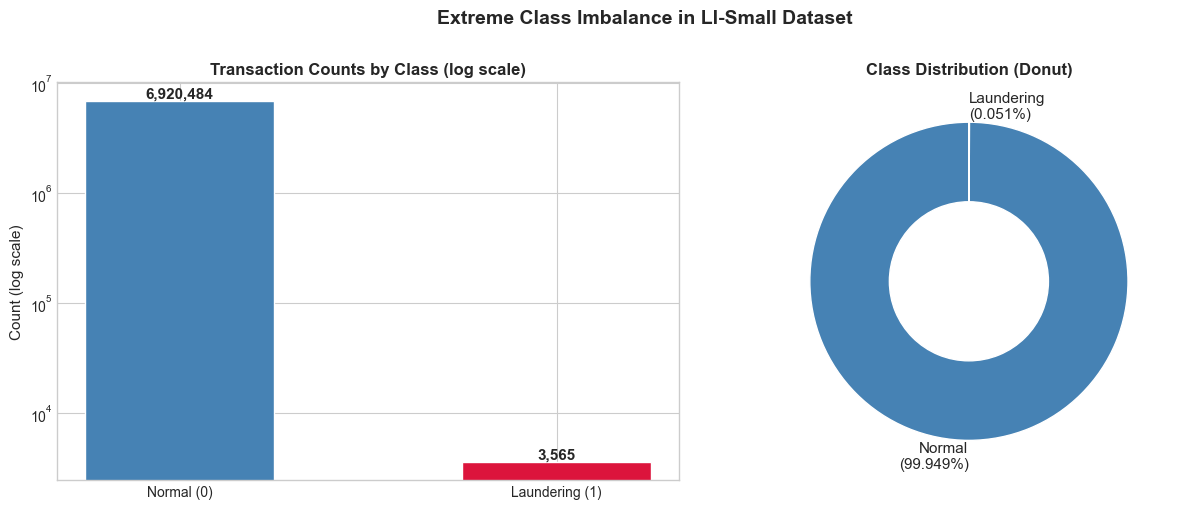

Total transactions:    6,924,049
Laundering rate:       0.0515%
Class ratio:           1941:1 (Normal:Laundering)


In [21]:
label_counts = df['Is Laundering'].value_counts()
laund_rate = df['Is Laundering'].mean() * 100
class_ratio = label_counts[0] / label_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: count bar chart on log scale to show both classes
colors = ['steelblue', 'crimson']
labels = ['Normal (0)', 'Laundering (1)']
axes[0].bar(labels, label_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_yscale('log')
axes[0].set_title('Transaction Counts by Class (log scale)', fontweight='bold')
axes[0].set_ylabel('Count (log scale)')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v * 1.0, f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right panel: donut chart showing percentage split
wedge_props = dict(width=0.5, edgecolor='white')
axes[1].pie(
    label_counts.values,
    labels=[f'Normal\n({100 - laund_rate:.3f}%)', f'Laundering\n({laund_rate:.3f}%)'],
    colors=colors,
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Distribution (Donut)', fontweight='bold')

plt.suptitle('Extreme Class Imbalance in LI-Small Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Total transactions:    {len(df):,}')
print(f'Laundering rate:       {laund_rate:.4f}%')
print(f'Class ratio:           {class_ratio:.0f}:1 (Normal:Laundering)')

### Interpretation

- The laundering rate is **~0.05%** - approximately 1 laundering transaction for every 1,941 normal ones.
- This extreme imbalance (1941:1 ratio) is a defining challenge of AML detection and mirrors real-world prevalence rates.
- **Implications for the GNN model:**
  - Standard cross-entropy loss will collapse to predicting the majority class. A **weighted loss** (e.g., weight the minority class by `~1000x`) is required.
  - Standard accuracy is a meaningless metric. We must use **Precision@K**, **Recall@K**, **AUCPR**, or **AUROC** for evaluation.
  - The LaundroGraph self-supervised approach avoids this problem entirely by not using labels during training, which is one of its key motivations.

## 4. Transaction Amount Analysis

Transaction amounts are one of the most informative features. Money laundering often involves:
- **Structuring** ("Smurfing"): splitting large amounts into many small transactions just below reporting thresholds (e.g., \$9,000–\$9,999)
- **Large layering transfers**: moving large sums through correspondent banks

We examine the raw and log-transformed distribution and compare laundering vs. normal transactions.

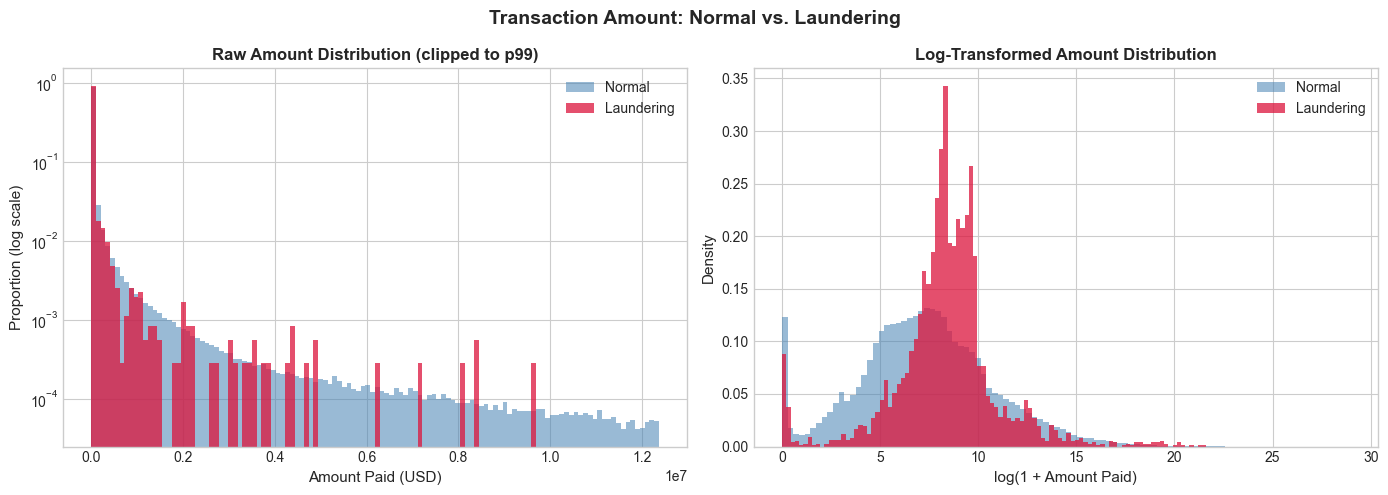

Amount Percentiles by Class:
Percentile    Normal ($) Laundering ($)
       p25        175.22       1,461.77
       p50      1,398.16       4,295.24
       p75     12,224.89      13,971.04
       p90    131,117.04      60,990.33
       p95    600,226.34     312,362.35
       p99 12,359,560.31  21,641,690.30


In [ ]:
normal_amounts = df[df['Is Laundering'] == 0]['Amount Paid']
laund_amounts  = df[df['Is Laundering'] == 1]['Amount Paid']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw distribution: shared bins, clipped range, independent normalization ---
clip_max = np.percentile(np.concatenate([normal_amounts, laund_amounts]), 99)
normal_clipped = normal_amounts[normal_amounts <= clip_max]
laund_clipped  = laund_amounts[laund_amounts <= clip_max]

# Compute shared bin edges from the clipped combined data
combined_clipped = np.concatenate([normal_clipped, laund_clipped])
bin_edges = np.histogram_bin_edges(combined_clipped, bins=120)

axes[0].hist(normal_clipped, bins=bin_edges, alpha=0.55, color='steelblue',
             label='Normal', density=False,
             weights=np.ones(len(normal_clipped)) / len(normal_amounts))  # normalize over full class size
axes[0].hist(laund_clipped,  bins=bin_edges, alpha=0.75, color='crimson',
             label='Laundering', density=False,
             weights=np.ones(len(laund_clipped)) / len(laund_amounts))
axes[0].set_yscale('log')
axes[0].set_xlabel('Amount Paid (USD)')
axes[0].set_ylabel('Proportion (log scale)')
axes[0].set_title('Raw Amount Distribution (clipped to p99)', fontweight='bold')
axes[0].legend()

# --- Log-transformed distribution ---
axes[1].hist(np.log1p(normal_amounts), bins=100, alpha=0.55, color='steelblue',
             label='Normal', density=True)
axes[1].hist(np.log1p(laund_amounts),  bins=100, alpha=0.75, color='crimson',
             label='Laundering', density=True)
axes[1].set_xlabel('log(1 + Amount Paid)')
axes[1].set_ylabel('Density')
axes[1].set_title('Log-Transformed Amount Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Transaction Amount: Normal vs. Laundering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Percentile comparison table
percentiles = [25, 50, 75, 90, 95, 99]
perc_df = pd.DataFrame({
    'Percentile': [f'p{p}' for p in percentiles],
    'Normal ($)': [f'{np.percentile(normal_amounts, p):,.2f}' for p in percentiles],
    'Laundering ($)': [f'{np.percentile(laund_amounts, p):,.2f}' for p in percentiles]
})
print('Amount Percentiles by Class:')
print(perc_df.to_string(index=False))

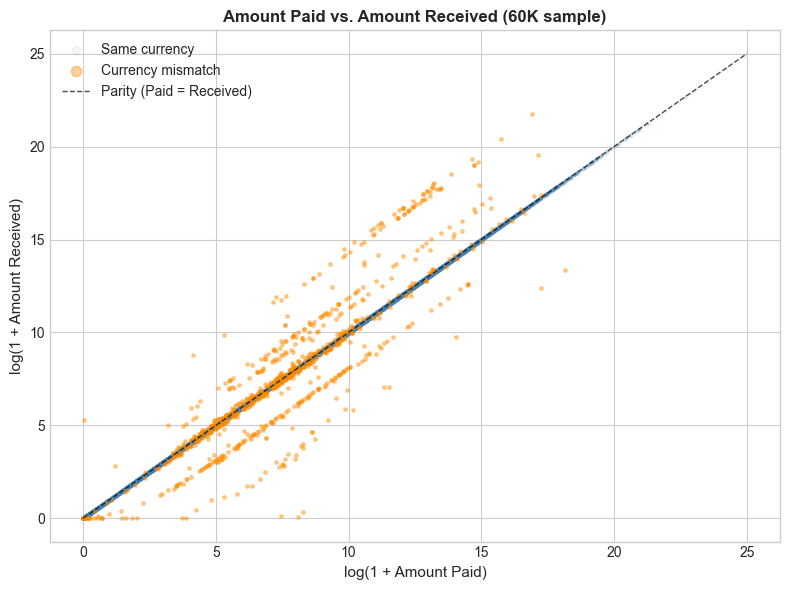

Currency mismatch rate: 1.42% of transactions


In [34]:
# Compare Amount Paid vs. Amount Received (currency conversion creates divergence)
# Sample 60k rows for scatter performance
sample = df.sample(n=60_000, random_state=42)
same_ccy = (sample['Payment Currency'] == sample['Receiving Currency'])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    np.log1p(sample[same_ccy]['Amount Paid']),
    np.log1p(sample[same_ccy]['Amount Received']),
    alpha=0.08, s=4, color='steelblue', label='Same currency'
)
ax.scatter(
    np.log1p(sample[~same_ccy]['Amount Paid']),
    np.log1p(sample[~same_ccy]['Amount Received']),
    alpha=0.4, s=6, color='darkorange', label='Currency mismatch'
)

# Parity line: perfect 1:1 relationship
max_val = 25
ax.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.7, label='Parity (Paid = Received)')

ax.set_xlabel('log(1 + Amount Paid)')
ax.set_ylabel('log(1 + Amount Received)')
ax.set_title('Amount Paid vs. Amount Received (60K sample)', fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

mismatch_rate = (~same_ccy).mean()
print(f'Currency mismatch rate: {mismatch_rate:.2%} of transactions')

### Interpretation

- The raw amount distribution is **highly right-skewed** (heavy tail): most transactions are small, but a few are very large. This is typical of real financial transaction data.
- After `log(1 + x)` transformation, the distribution becomes approximately bell-shaped, confirming log-normal behaviour. **Log-transforming amounts is essential** before feeding them into any ML model.
- Laundering transactions show **no single amount threshold** that cleanly separates them from normal ones - however, their log-transformed distribution is more **concentrated and peaks at mid-range values** ( log(amount) ≈ 7–9 (roughly $1K–$8K) ), suggesting launderers tend to favour mid-sized transactions rather than very small or very large ones. This makes pure amount-based detection insufficient, but amount remains a **weak signal** worth retaining as a feature.
- The `Amount Paid vs. Amount Received` scatter shows that most transactions lie on the parity diagonal (same currency), while **currency-mismatch** transactions diverge from it due to exchange rate conversion.


## 5. Temporal Patterns

Financial transactions are not uniformly distributed in time. Temporal features such as **hour of day** and **day of week** can reveal behavioural patterns. For instance:
- Legitimate businesses transact during business hours; automated laundering may occur at odd hours.
- Weekend activity is lower for normal transactions, but laundering may be insensitive to weekdays.

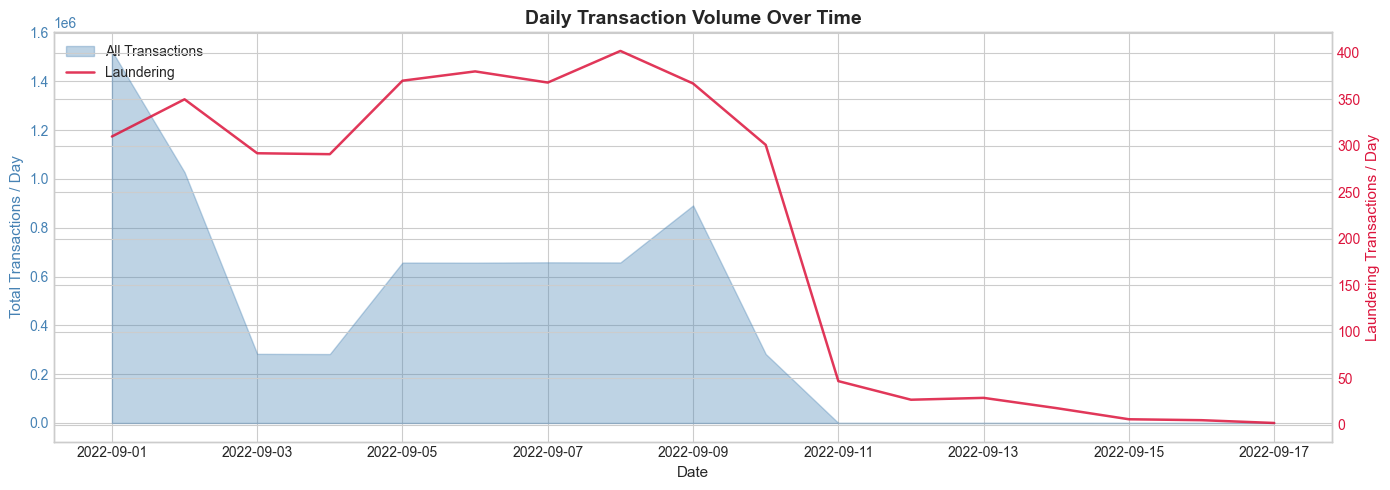

Average transactions per day: 407,297
Average laundering per day:   209.7


In [41]:
# Aggregate to daily counts
df['Date'] = df['Timestamp'].dt.date
daily = df.groupby('Date').agg(
    Total=('Is Laundering', 'count'),
    Laundering=('Is Laundering', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Total transaction volume as filled area
ax1.fill_between(daily['Date'], daily['Total'],
                 alpha=0.35, color='steelblue', label='All Transactions')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Transactions / Day', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Laundering counts on secondary axis
ax2 = ax1.twinx()
ax2.plot(daily['Date'], daily['Laundering'],
         color='crimson', lw=1.8, label='Laundering', alpha=0.85)
ax2.set_ylabel('Laundering Transactions / Day', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Daily Transaction Volume Over Time', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print(f'Average transactions per day: {daily["Total"].mean():,.0f}')
print(f'Average laundering per day:   {daily["Laundering"].mean():,.1f}')

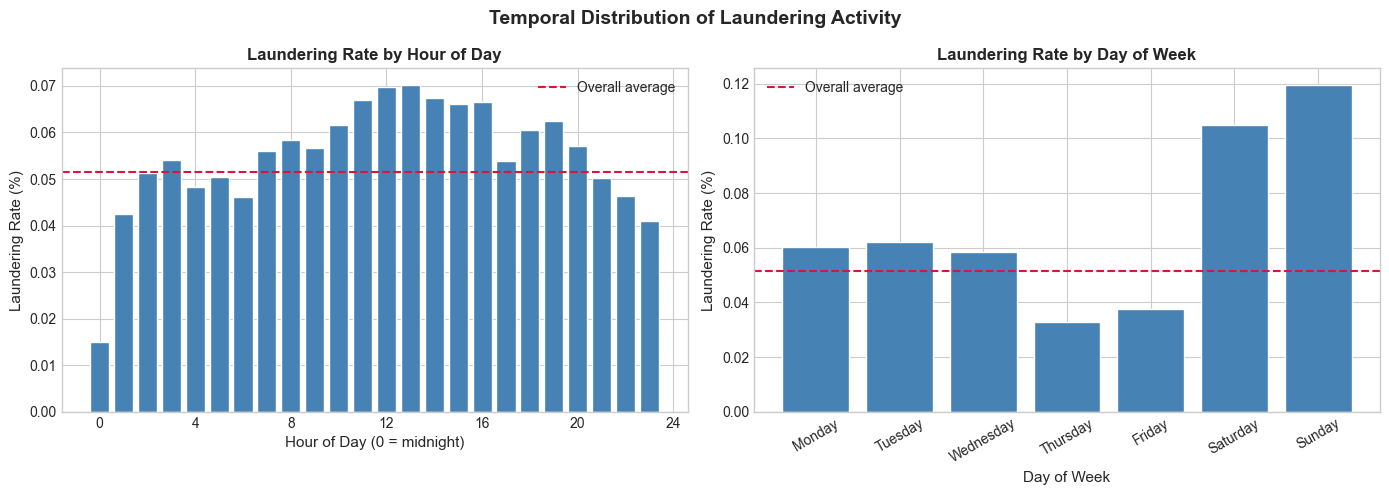

Hour with highest laundering rate: 13:00
Day  with highest laundering rate: Sunday


In [42]:
# Extract temporal features
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

# Laundering rate by hour of day
hourly = df.groupby('Hour')['Is Laundering'].agg(['count', 'sum', 'mean']).reset_index()
hourly.columns = ['Hour', 'Count', 'Laund_Count', 'Laund_Rate']

# Laundering rate by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('DayOfWeek')['Is Laundering'].mean().reindex(day_order) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly pattern
axes[0].bar(hourly['Hour'], hourly['Laund_Rate'] * 100,
            color='steelblue', edgecolor='white', width=0.8)
axes[0].axhline(df['Is Laundering'].mean() * 100, color='crimson',
                linestyle='--', lw=1.5, label='Overall average')
axes[0].set_xlabel('Hour of Day (0 = midnight)')
axes[0].set_ylabel('Laundering Rate (%)')
axes[0].set_title('Laundering Rate by Hour of Day', fontweight='bold')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(4))
axes[0].legend()

# Day-of-week pattern
axes[1].bar(day_order, dow.values, color='steelblue', edgecolor='white')
axes[1].axhline(df['Is Laundering'].mean() * 100, color='crimson',
                linestyle='--', lw=1.5, label='Overall average')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Laundering Rate (%)')
axes[1].set_title('Laundering Rate by Day of Week', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Temporal Distribution of Laundering Activity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Hour with highest laundering rate: {hourly.loc[hourly["Laund_Rate"].idxmax(), "Hour"]}:00')
print(f'Day  with highest laundering rate: {dow.idxmax()}')

### Interpretation

- Transaction volume is **not stable over time** - it drops sharply after 2022-09-10 and approaches zero by 2022-09-17, indicating the dataset covers a truncated observation window rather than a steady-state system. This temporal imbalance should be accounted for during train/test splitting to avoid leakage.
- The hourly laundering rate is **lowest around midnight (~0.015%)** and peaks during **midday hours (12:00–16:00, ~0.07%)**, suggesting laundering activity in this dataset follows business hours rather than off-peak evasion patterns.
- Weekend days (Saturday and Sunday) show **significantly elevated laundering rates** (~0.10–0.12% vs. ~0.05% average), which is a potentially useful signal - laundering activity disproportionately concentrates on weekends when institutional oversight is reduced.
- **Feature engineering implication:** Time features should be **cyclically encoded** using `sin(2π·hour/24)` and `cos(2π·hour/24)` to preserve continuity between hour 23 and hour 0. Day-of-week should be similarly encoded. Both will be included as transaction node features in the GNN.

## 6. Payment Format Analysis

The method of payment is a strong signal in AML. The dataset includes 7 payment formats:
- **Cheque / Credit Card**: Highest volume formats (36% and 26% of all transactions), but laundering rates are below the overall average - launderers avoid high-volume, well-monitored channels
- **ACH**: Moderate volume (11.5%) but by far the **highest laundering rate (~0.33%)**, roughly 6× the overall average - the dominant risk signal in this dataset
- **Bitcoin**: Low volume (4.5%) but laundering rate above average - consistent with its pseudonymous nature
- **Cash**: Despite real-world associations with placement-stage laundering, Cash shows a **below-average laundering rate** in this synthetic dataset
- **Reinvestment / Wire**: Zero laundering transactions recorded - effectively clean channels in this data

**Key implication:** Payment format is a strong categorical feature for the GNN. ACH in particular should be a high-weight signal. One-hot encoding of payment format should be included in transaction edge features.

In [45]:
df['Payment Format'].value_counts()

Payment Format
Cheque          2503158
Credit Card     1780389
ACH              796581
Cash             655688
Reinvestment     650458
Bitcoin          309208
Wire             228567
Name: count, dtype: int64

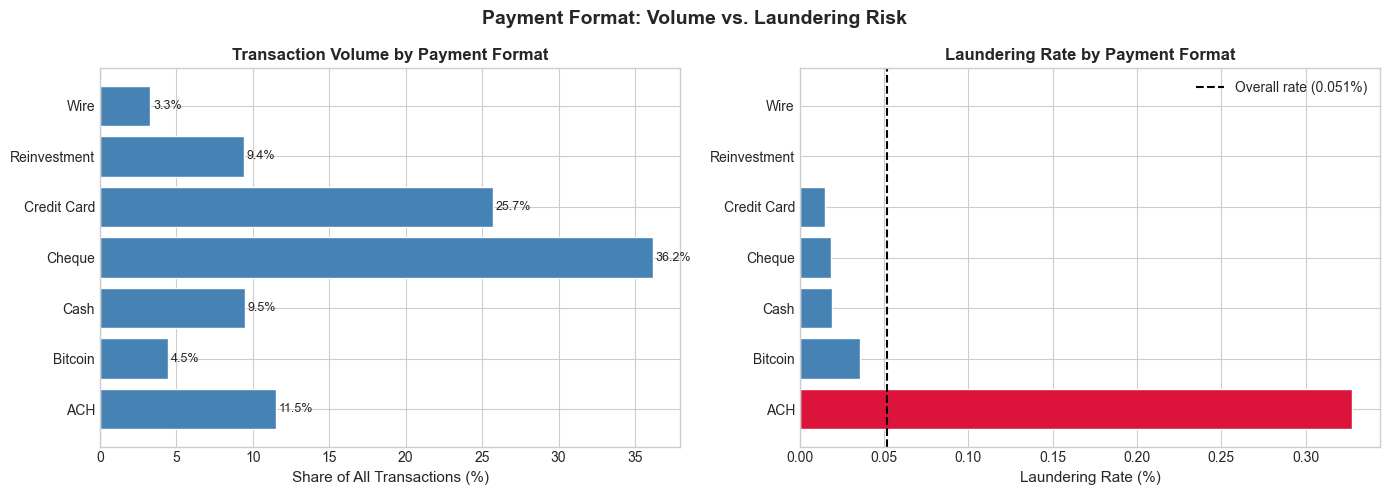


Payment Format Statistics:
Payment Format   Count  Laund_Count  Laund_Rate  Share (%)
           ACH  796581         2611      0.0033    11.5046
       Bitcoin  309208          110      0.0004     4.4657
          Cash  655688          124      0.0002     9.4697
        Cheque 2503158          459      0.0002    36.1517
   Credit Card 1780389          261      0.0001    25.7131
  Reinvestment  650458            0      0.0000     9.3942
          Wire  228567            0      0.0000     3.3011


In [ ]:
fmt_stats = (
    df.groupby('Payment Format')
    .agg(Count=('Is Laundering', 'count'),
         Laund_Count=('Is Laundering', 'sum'),
         Laund_Rate=('Is Laundering', 'mean'))
    .reset_index()
    .sort_values('Laund_Rate', ascending=False)
)
fmt_stats['Share (%)'] = fmt_stats['Count'] / fmt_stats['Count'].sum() * 100

overall_rate = df['Is Laundering'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: share of transaction volume
axes[0].barh(fmt_stats['Payment Format'], fmt_stats['Share (%)'],
             color='steelblue', edgecolor='white')
axes[0].set_xlabel('Share of All Transactions (%)')
axes[0].set_title('Transaction Volume by Payment Format', fontweight='bold')
for i, v in enumerate(fmt_stats['Share (%)']):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# Right: laundering rate per format (red = above average, blue = below)
bar_colors = ['crimson' if r > overall_rate / 100 else 'steelblue'
              for r in fmt_stats['Laund_Rate']]
axes[1].barh(fmt_stats['Payment Format'], fmt_stats['Laund_Rate'] * 100,
             color=bar_colors, edgecolor='white')
axes[1].axvline(overall_rate, color='black', linestyle='--',
                lw=1.5, label=f'Overall rate ({overall_rate:.3f}%)')
axes[1].set_xlabel('Laundering Rate (%)')
axes[1].set_title('Laundering Rate by Payment Format', fontweight='bold')
axes[1].legend()

plt.suptitle('Payment Format: Volume vs. Laundering Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed table
print('\nPayment Format Statistics:')
print(fmt_stats[['Payment Format', 'Count', 'Laund_Count', 'Laund_Rate', 'Share (%)']]
      .to_string(index=False))

### Interpretation

- **ACH** is the most significant risk signal by far - despite representing only 11.5% of 
  transaction volume, it carries a laundering rate of ~0.33%, roughly **6× the overall 
  average**. This may reflect ACH's use in automated, high-frequency layering patterns.
- **Reinvestment and Wire** have **zero laundering transactions**, making them effectively 
  clean channels in this dataset. Reinvestment represents intra-account bookkeeping rather 
  than true fund movement.
- **Bitcoin** has a below-average volume share (4.5%) but an above-average laundering rate, 
  consistent with its pseudonymous nature enabling harder-to-trace transfers.
- **Cheque and Credit Card**, despite dominating transaction volume (36% and 26% 
  respectively), show below-average laundering rates - launderers appear to avoid 
  high-volume, heavily monitored retail channels.
- **Cash**, contrary to real-world AML intuition about placement-stage risk, shows a 
  **below-average laundering rate** in this synthetic dataset - a limitation worth noting 
  when comparing to real-world expectations.
- **Feature engineering implication:** Payment format should be **one-hot encoded** as a 
  transaction edge feature. An explicit `Is_ACH` binary flag is worth deriving as a 
  targeted high-risk indicator given ACH's dominant laundering signal.

## 7. Currency Analysis

Multi-currency transactions are a hallmark of **layering** - the second stage of money 
laundering where funds are moved through multiple jurisdictions to obscure their origin. 
When the payment currency differs from the receiving currency, it indicates a **cross-border 
transaction** where funds move between accounts operating in different currencies, whether 
through explicit FX conversion or cross-border clearing. In this dataset, approximately 
**1.42% of transactions** involve a currency mismatch between the sent and received amounts. 
We examine whether this mismatch is associated with elevated laundering risk.

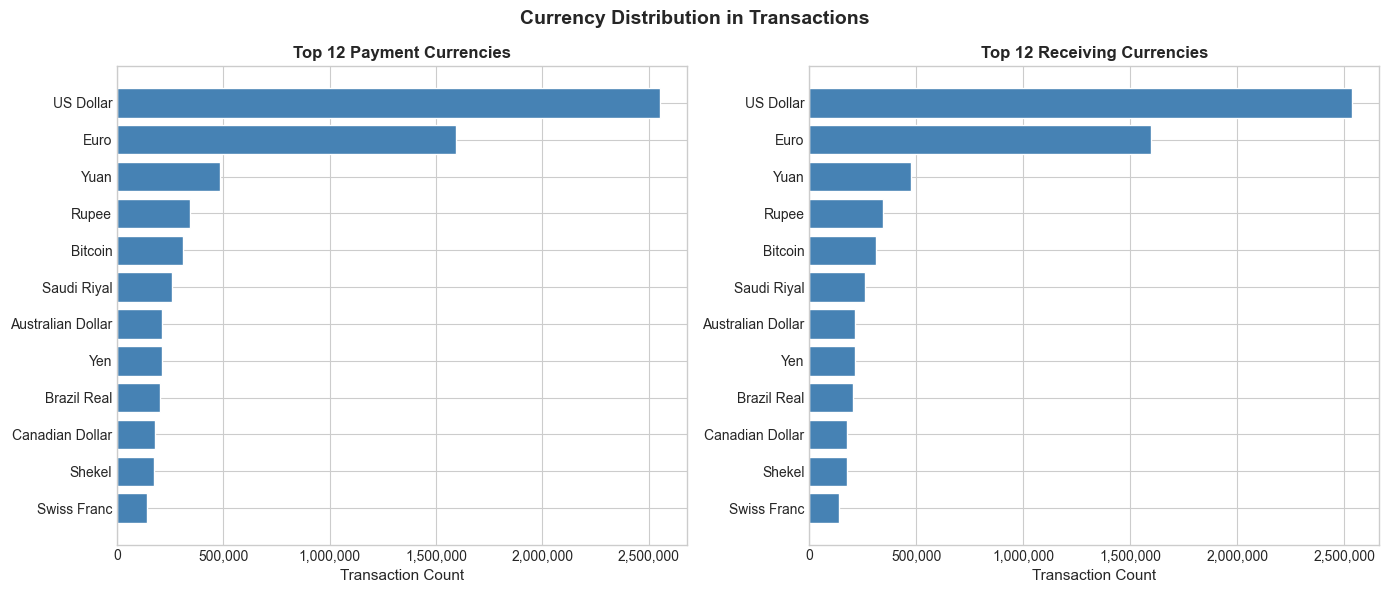

Unique payment currencies:   15
Unique receiving currencies: 15


In [47]:
# Top currencies by frequency
top_pay = df['Payment Currency'].value_counts().head(12)
top_rec = df['Receiving Currency'].value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pay.index[::-1], top_pay.values[::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Top 12 Payment Currencies', fontweight='bold')
axes[0].set_xlabel('Transaction Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(top_rec.index[::-1], top_rec.values[::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 12 Receiving Currencies', fontweight='bold')
axes[1].set_xlabel('Transaction Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Currency Distribution in Transactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Unique payment currencies:   {df["Payment Currency"].nunique()}')
print(f'Unique receiving currencies: {df["Receiving Currency"].nunique()}')

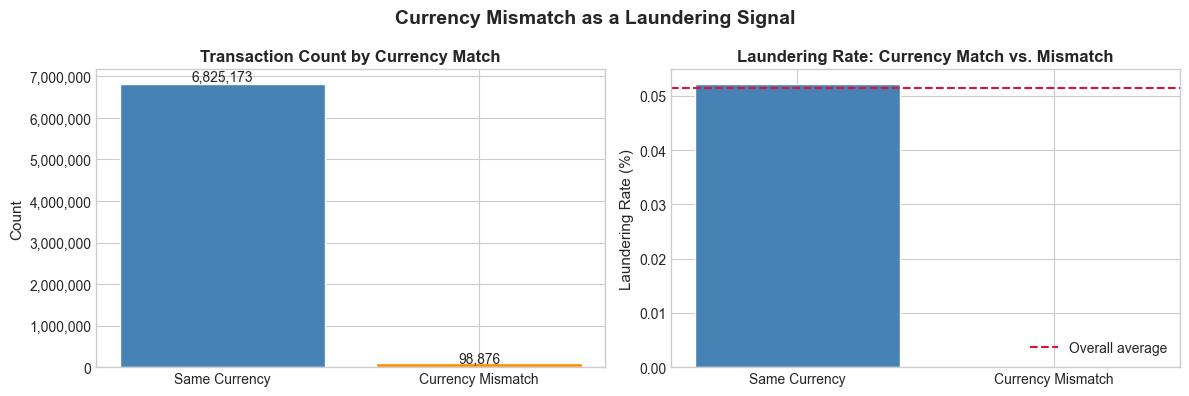

Currency mismatch rate: 1.43% of all transactions

            Label   Count  Laund_Rate
    Same Currency 6825173      0.0005
Currency Mismatch   98876      0.0000


In [48]:
# Flag transactions where payment and receiving currencies differ
df['Currency Mismatch'] = (df['Payment Currency'] != df['Receiving Currency']).astype(int)

mismatch_stats = (
    df.groupby('Currency Mismatch')['Is Laundering']
    .agg(['count', 'mean'])
    .reset_index()
)
mismatch_stats.columns = ['Mismatch', 'Count', 'Laund_Rate']
mismatch_stats['Label'] = mismatch_stats['Mismatch'].map(
    {0: 'Same Currency', 1: 'Currency Mismatch'}
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume breakdown
axes[0].bar(mismatch_stats['Label'], mismatch_stats['Count'],
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[0].set_title('Transaction Count by Currency Match', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate(mismatch_stats['Count']):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=10)

# Laundering rate comparison
axes[1].bar(mismatch_stats['Label'], mismatch_stats['Laund_Rate'] * 100,
            color=['steelblue', 'darkorange'], edgecolor='white')
axes[1].axhline(df['Is Laundering'].mean() * 100, color='crimson',
                linestyle='--', lw=1.5, label='Overall average')
axes[1].set_title('Laundering Rate: Currency Match vs. Mismatch', fontweight='bold')
axes[1].set_ylabel('Laundering Rate (%)')
axes[1].legend()

plt.suptitle('Currency Mismatch as a Laundering Signal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mismatch_rate = df['Currency Mismatch'].mean() * 100
print(f'Currency mismatch rate: {mismatch_rate:.2f}% of all transactions')
print()
print(mismatch_stats[['Label', 'Count', 'Laund_Rate']].to_string(index=False))

### Interpretation

- **US Dollar dominates** both payment and receiving currencies, consistent with a synthetic 
  dataset modelled on international banking. All 15 currencies appear symmetrically on both 
  sides, confirming the dataset is internally consistent.
- **Currency mismatch transactions** (1.43% of all transactions) show a **zero laundering 
  rate** - contrary to real-world AML intuition, cross-border currency conversion is *not* 
  a laundering signal in this synthetic dataset.
- **Feature engineering implication:** Despite its theoretical relevance, `Is_Currency_Mismatch` 
  carries **no predictive signal** in this dataset and should be deprioritized or dropped 
  as a feature.

## 8. Network / Graph Structure Analysis

The fundamental motivation for using **Graph Neural Networks** is that money laundering is 
not a property of individual transactions but of **patterns across connected sequences of 
transactions**. A single transaction may look innocent in isolation, but its position within 
a network - as part of a cycle, fan-in hub, or scatter-gather pattern - can reveal 
laundering behaviour.

This section examines the graph topology of the transaction network:

- **Self-loops** (same account → same account): likely correspond to Reinvestment entries
- **Degree distribution** (in-degree and out-degree per account): identifies hub accounts 
  that consolidate or distribute funds - key structural features for GNN node embeddings
- **Power-law degree distribution**: a signature of real financial networks, confirming 
  the synthetic data's structural realism
- **Laundering node degree**: whether laundering accounts have systematically different 
  connectivity than normal accounts

In [51]:
# Self-loop analysis: transactions where sender == receiver account
self_loop_mask = df['From Account'] == df['To Account']
self_loops = df[self_loop_mask]

print(f'Self-loop transactions:     {len(self_loops):,} ({self_loop_mask.mean():.2%} of total)')
print(f'Self-loop laundering rate:  {self_loops["Is Laundering"].mean():.6f}')
print(f'\nPayment Format breakdown for self-loops:')
print(self_loops['Payment Format'].value_counts().to_string())

Self-loop transactions:     804,477 (11.62% of total)
Self-loop laundering rate:  0.000004

Payment Format breakdown for self-loops:
Payment Format
Reinvestment    650458
ACH              96141
Bitcoin          44982
Cheque            6341
Credit Card       4308
Cash              1471
Wire               776


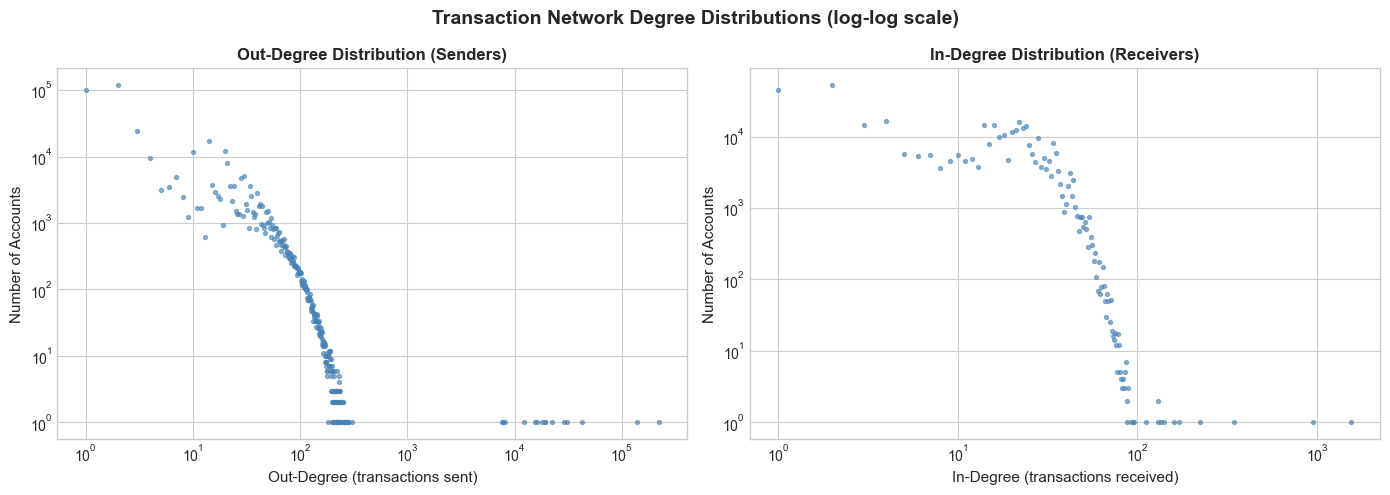

Out-Degree: mean=14.7, median=2, p95=57, max=222037
In-Degree: mean=15.8, median=16, p95=39, max=1553


In [ ]:
# Compute out-degree (transactions sent) and in-degree (transactions received) per account
# Exclude self-loops from degree computation for a cleaner network view
real_txn = df[~self_loop_mask].copy()

out_deg = real_txn.groupby('From Account').size().rename('Out_Degree')
in_deg  = real_txn.groupby('To Account').size().rename('In_Degree')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Out-degree distribution - log-log reveals power-law behaviour
out_counts = out_deg.value_counts().sort_index()
axes[0].scatter(out_counts.index, out_counts.values, s=8, alpha=0.6, color='steelblue')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Out-Degree (transactions sent)')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_title('Out-Degree Distribution (Senders)', fontweight='bold')

# In-degree distribution
in_counts = in_deg.value_counts().sort_index()
axes[1].scatter(in_counts.index, in_counts.values, s=8, alpha=0.6, color='steelblue')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('In-Degree (transactions received)')
axes[1].set_ylabel('Number of Accounts')
axes[1].set_title('In-Degree Distribution (Receivers)', fontweight='bold')

plt.suptitle('Transaction Network Degree Distributions (log-log scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Degree statistics summary
for name, deg_series in [('Out-Degree', out_deg), ('In-Degree', in_deg)]:
    print(f'{name}: mean={deg_series.mean():.1f}, '
          f'median={deg_series.median():.0f}, '
          f'p95={deg_series.quantile(0.95):.0f}, '
          f'max={deg_series.max()}')

In [53]:
# Join laundering labels to degree statistics
# For each account, compute: total transactions sent/received and how many were laundering
out_stats = real_txn.groupby('From Account').agg(
    Out_Degree=('Is Laundering', 'count'),
    Laund_Sent=('Is Laundering', 'sum')
)
out_stats['Laund_Rate_Out'] = out_stats['Laund_Sent'] / out_stats['Out_Degree']

in_stats = real_txn.groupby('To Account').agg(
    In_Degree=('Is Laundering', 'count'),
    Laund_Received=('Is Laundering', 'sum')
)
in_stats['Laund_Rate_In'] = in_stats['Laund_Received'] / in_stats['In_Degree']

# Top 15 most active senders
print('Top 15 Most Active Senders (Fan-Out candidates):')
print(out_stats.nlargest(15, 'Out_Degree')[['Out_Degree', 'Laund_Sent', 'Laund_Rate_Out']]
      .reset_index().rename(columns={'From Account': 'Account'})
      .to_string(index=False))

# Top 15 most active receivers (Fan-In candidates)
print('\nTop 15 Most Active Receivers (Fan-In candidates):')
print(in_stats.nlargest(15, 'In_Degree')[['In_Degree', 'Laund_Received', 'Laund_Rate_In']]
      .reset_index().rename(columns={'To Account': 'Account'})
      .to_string(index=False))

# Compare laundering rate: high in-degree vs. rest
p99_threshold = in_deg.quantile(0.99)
high_indeg_accs = in_deg[in_deg >= p99_threshold].index
laund_rate_high = in_stats.loc[in_stats.index.isin(high_indeg_accs), 'Laund_Rate_In'].mean()
laund_rate_all  = real_txn['Is Laundering'].mean()

print(f'\nTop 1% high in-degree accounts (in_degree >= {p99_threshold:.0f}): {len(high_indeg_accs):,} accounts')
print(f'  Avg laundering rate (these accounts): {laund_rate_high:.4%}')
print(f'  Overall transaction laundering rate:  {laund_rate_all:.4%}')

Top 15 Most Active Senders (Fan-Out candidates):
  Account  Out_Degree  Laund_Sent  Laund_Rate_Out
10042B660      222037         314          0.0014
10042B6A8      138777         196          0.0014
10042B6F0       42385          48          0.0011
10042B780       30802          32          0.0010
10042BA51       28932          31          0.0011
10042BA08       22417          39          0.0017
10042B930       19445          19          0.0010
10042B8A0       19254          25          0.0013
10042B738       18213          28          0.0015
10042B9C0       16266          29          0.0018
10042B858       15684          27          0.0017
10042B978       12227          21          0.0017
10042B810        8145          18          0.0022
10042B8E8        7737          11          0.0014
10042B7C8        7670          12          0.0016

Top 15 Most Active Receivers (Fan-In candidates):
  Account  In_Degree  Laund_Received  Laund_Rate_In
10042B660       1553               0         0.0

### Interpretation

- **Self-loop transactions** (11.62% of total) are dominated by Reinvestment (650K) but also 
  include ACH (96K) and Bitcoin (45K) self-loops. All have near-zero laundering rates and 
  are excluded from degree computation to avoid inflating connectivity metrics.
- Degree distributions follow a **power law** on log-log axes, confirming a **scale-free 
  network** structure typical of real financial networks. The median out-degree is just 2, 
  but the max reaches 222,037 - extreme hub concentration.
- **Counter-intuitively, high in-degree hub accounts are cleaner than average** (0.019% vs. 
  0.058% overall). The most active hubs appear to be legitimate high-volume institutions 
  (e.g. banks, clearinghouses), not laundering nodes.
- **GNN implication:** Laundering likely occurs in **mid-degree accounts** rather than 
  extreme hubs. GNN neighbourhood aggregation should capture this - a node embedded in a 
  suspicious mid-size subgraph will look different from both isolated low-degree nodes and 
  legitimate high-volume hubs.

## 9. Account Entity Analysis

The `LI-Small_accounts.csv` file maps each account to a **bank name**, **bank ID**, and 
**entity name** (which encodes the entity type: Corporation, Partnership, Individual, etc.). 

In real-world AML, different entity types carry different risk profiles - shell corporations 
are commonly used for layering, while individual accounts tend to appear in placement and 
integration stages. We examine whether these patterns hold in the AMLworld synthetic data 
by analysing:

- **Entity type distribution** across accounts
- **Laundering rate by entity type** - whether certain entity types are disproportionately 
  involved in laundering
- **Bank-level analysis** - whether laundering concentrates in specific banks

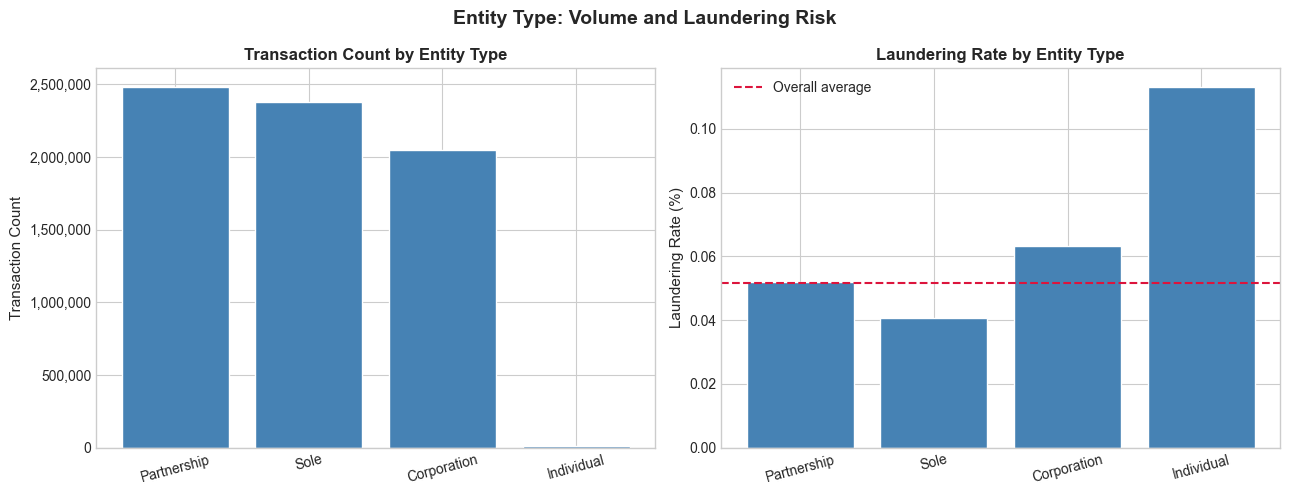


Entity Type Summary:
Entity Type   Count  Laundering  Laund_Rate
Partnership 2484005        1288      0.0005
       Sole 2378575         970      0.0004
Corporation 2048245        1292      0.0006
 Individual   13249          15      0.0011


In [58]:
# Map sender accounts to entity type using the accounts master file
accounts_map = accounts[['Account Number', 'Entity Name']].copy()
accounts_map['Entity Type'] = accounts_map['Entity Name'].str.extract(r'^([A-Za-z]+)', expand=False)

# Merge sender account entity info
df_ent = df[['From Account', 'Is Laundering']].merge(
    accounts_map.rename(columns={'Account Number': 'From Account'}),
    on='From Account',
    how='left'
)

# Entity type distribution and laundering rate
ent_stats = (
    df_ent.groupby('Entity Type')['Is Laundering']
    .agg(['count', 'sum', 'mean'])
    .reset_index()
)
ent_stats.columns = ['Entity Type', 'Count', 'Laundering', 'Laund_Rate']
ent_stats = ent_stats.sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Transaction count by entity type
axes[0].bar(ent_stats['Entity Type'], ent_stats['Count'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Count by Entity Type', fontweight='bold')
axes[0].set_ylabel('Transaction Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Laundering rate by entity type
axes[1].bar(ent_stats['Entity Type'], ent_stats['Laund_Rate'] * 100,
            color='steelblue', edgecolor='white')
axes[1].axhline(df['Is Laundering'].mean() * 100, color='crimson',
                linestyle='--', lw=1.5, label='Overall average')
axes[1].set_title('Laundering Rate by Entity Type', fontweight='bold')
axes[1].set_ylabel('Laundering Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.suptitle('Entity Type: Volume and Laundering Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nEntity Type Summary:')
print(ent_stats.to_string(index=False))

In [62]:
df.drop_duplicates().shape

(6924041, 15)

### Interpretation

- **Partnership, Sole, and Corporation** entity types dominate transaction volume relatively 
  equally (~2–2.5M each), while **Individual** accounts are rare in terms of volume.
- **Individual accounts have by far the highest laundering rate** (~0.12%), more than **2× 
  the overall average** - despite their low transaction volume, they are the highest-risk 
  entity type in this dataset.
- **Corporation** accounts are the only business entity type with an **above-average 
  laundering rate** (~0.063%), consistent with their use as shell companies in layering.
- **Sole** proprietorships show the **lowest laundering rate** (~0.040%), well below average - suggesting they predominantly represent legitimate small business activity.
- **Partnership** accounts sit just below the overall average, indicating moderate but not 
  elevated risk.
- **Feature engineering implication:** Entity type should be **one-hot encoded** as an 
  account node feature in the GNN. An explicit `Is_Individual` flag is worth deriving as 
  a targeted high-risk indicator, given individuals show disproportionate laundering 
  involvement despite low transaction volume.

## 10. Laundering Pattern Typologies

The `LI-Small_Patterns.txt` file contains the **ground-truth annotations** of every 
laundering attempt in the dataset, delimited by `BEGIN/END LAUNDERING ATTEMPT - <TYPE>` 
markers.

Understanding the typology distribution is critical for:
1. Knowing **which graph structures** the GNN must learn to detect
2. Understanding **where the GNN may struggle** (e.g., simple star patterns vs. complex 
   multi-hop chains)

The 8 key pattern types described in Altman et al. (2023):

| Pattern | Graph Shape | Description |
|---------|-------------|-------------|
| **Fan-Out** | Star (one→many) | Single account distributes to many recipients |
| **Fan-In** | Star (many→one) | Many accounts consolidate into one |
| **Gather-Scatter** | Hub | Fan-in and fan-out at the same vertex |
| **Scatter-Gather** | Bipartite | Fan-out then fan-in through shared intermediaries |
| **Cycle** | Ring | Funds circulate back to the originating account |
| **Random** | Random walk | Multi-hop chain without returning to origin |
| **Bipartite** | Bipartite | Funds move from a set of sources to a set of destinations |
| **Stack** | Layered bipartite | Bipartite pattern with an additional intermediate layer |

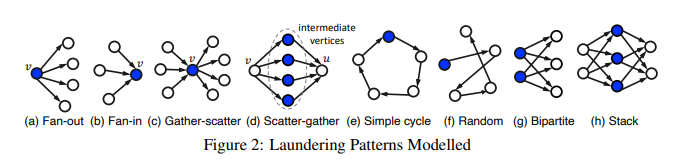

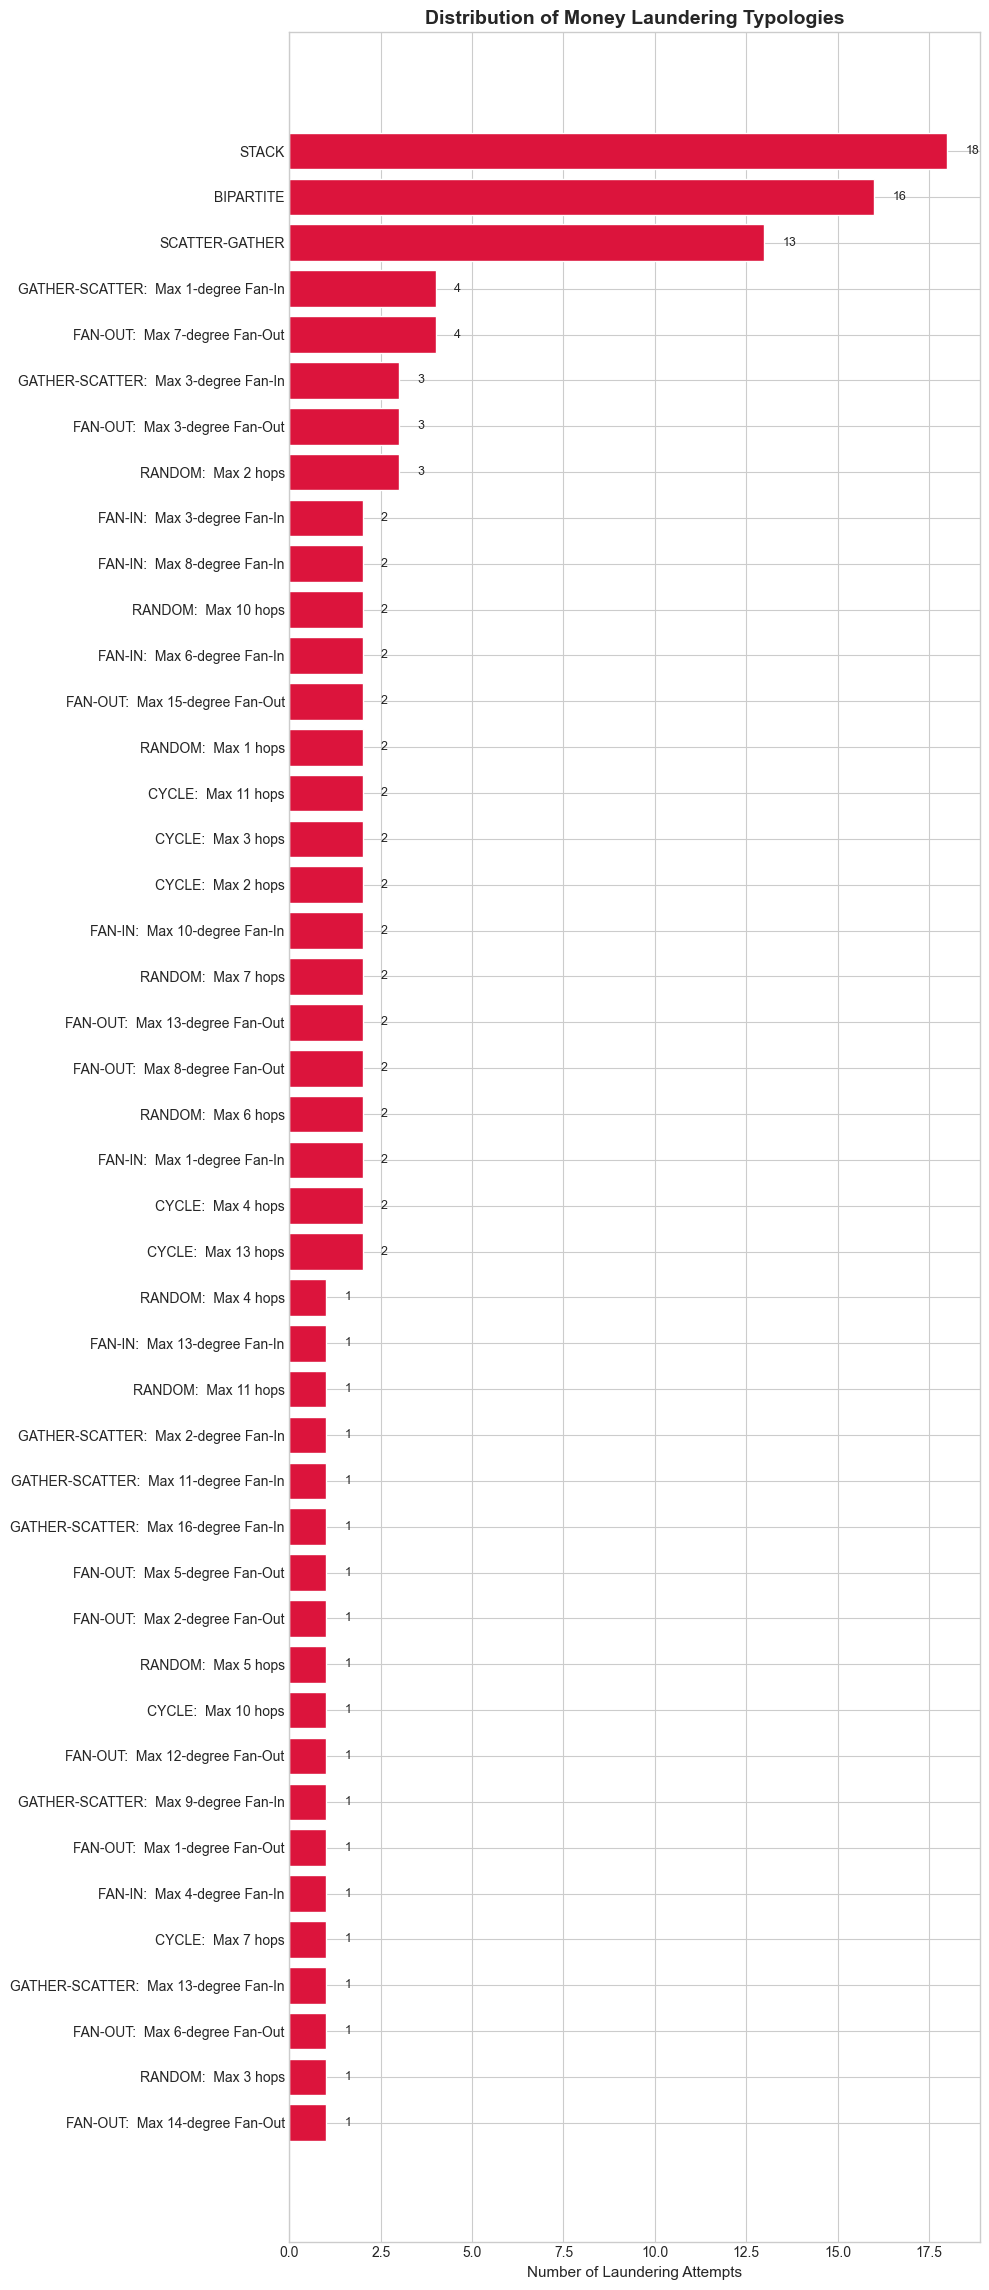

Total laundering pattern attempts in file: 117
Distinct pattern types: 44

Pattern Type Counts:
  STACK: 18
  BIPARTITE: 16
  SCATTER-GATHER: 13
  GATHER-SCATTER:  Max 1-degree Fan-In: 4
  FAN-OUT:  Max 7-degree Fan-Out: 4
  GATHER-SCATTER:  Max 3-degree Fan-In: 3
  FAN-OUT:  Max 3-degree Fan-Out: 3
  RANDOM:  Max 2 hops: 3
  FAN-IN:  Max 3-degree Fan-In: 2
  FAN-IN:  Max 8-degree Fan-In: 2
  RANDOM:  Max 10 hops: 2
  FAN-IN:  Max 6-degree Fan-In: 2
  FAN-OUT:  Max 15-degree Fan-Out: 2
  RANDOM:  Max 1 hops: 2
  CYCLE:  Max 11 hops: 2
  CYCLE:  Max 3 hops: 2
  CYCLE:  Max 2 hops: 2
  FAN-IN:  Max 10-degree Fan-In: 2
  RANDOM:  Max 7 hops: 2
  FAN-OUT:  Max 13-degree Fan-Out: 2
  FAN-OUT:  Max 8-degree Fan-Out: 2
  RANDOM:  Max 6 hops: 2
  FAN-IN:  Max 1-degree Fan-In: 2
  CYCLE:  Max 4 hops: 2
  CYCLE:  Max 13 hops: 2
  RANDOM:  Max 4 hops: 1
  FAN-IN:  Max 13-degree Fan-In: 1
  RANDOM:  Max 11 hops: 1
  GATHER-SCATTER:  Max 2-degree Fan-In: 1
  GATHER-SCATTER:  Max 11-degree Fan-In: 1

In [64]:
# Parse the patterns file to extract and count laundering typologies
with open('Data/LI-Small_Patterns.txt', 'r') as f:
    pattern_text = f.read()

# Extract all pattern type names from BEGIN lines
pattern_names = re.findall(r'BEGIN LAUNDERING ATTEMPT - (.+)', pattern_text)
pattern_counts = Counter(pattern_names)

# Sort by frequency
sorted_patterns = sorted(pattern_counts.items(), key=lambda x: -x[1])
names, counts = zip(*sorted_patterns) if sorted_patterns else ([], [])

# Visualise pattern distribution
fig, ax = plt.subplots(figsize=(10, max(4, len(names) * 0.5 + 1)))
bars = ax.barh(list(names)[::-1], list(counts)[::-1],
               color='crimson', edgecolor='white')
ax.set_xlabel('Number of Laundering Attempts')
ax.set_title('Distribution of Money Laundering Typologies', fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, list(counts)[::-1])):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Total laundering pattern attempts in file: {len(pattern_names):,}')
print(f'Distinct pattern types: {len(pattern_counts)}')
print('\nPattern Type Counts:')
for name, count in sorted_patterns:
    print(f'  {name}: {count}')

# Show one example of each pattern type
print('\n--- Example of first pattern ---')
if pattern_names:
    first_type = pattern_names[0]
    start = pattern_text.find(f'BEGIN LAUNDERING ATTEMPT - {first_type}')
    end   = pattern_text.find(f'END LAUNDERING ATTEMPT - {first_type}', start) + len(f'END LAUNDERING ATTEMPT - {first_type}')
    print(pattern_text[start:end])

### Interpretation

- The dataset contains **117 laundering attempts** across **8 base pattern types**, with 44 
  distinct parameterised variants (e.g. "Fan-Out: Max 7-degree").
- **Stack (18) and Bipartite (16)** are the most frequent patterns - both involve moving 
  funds through structured layers of accounts, requiring **multi-hop GNN aggregation** to 
  detect (2+ layers minimum).
- **Scatter-Gather (13)** is the third most common - funds fan-out to intermediaries then 
  consolidate, creating a characteristic bipartite subgraph structure.
- **Fan-In and Fan-Out** patterns appear with varying degree parameters (1–16), meaning the 
  GNN must generalise across different hub sizes rather than memorising a fixed topology.
- **Cycle and Random** patterns are the most topologically challenging - Cycles require the 
  GNN to detect closed loops, while Random multi-hop walks lack a clear structural signature 
  and may resemble legitimate transaction chains.
- **GNN implication:** The dominance of Stack and Bipartite patterns motivates using at 
  least **2-layer message passing** with edge features, as single-hop aggregation cannot 
  capture the layered structure of these patterns.

## 11. Summary Statistics & Feature Engineering Implications for GNN

This final section consolidates the key findings from the EDA and maps them directly to decisions in the GNN pipeline.

In [70]:
# Compute summary statistics
n_unique_senders   = df['From Account'].nunique()
n_unique_receivers = df['To Account'].nunique()
n_unique_accounts  = pd.concat([df['From Account'], df['To Account']]).nunique()
laund_rate_pct     = df['Is Laundering'].mean() * 100
class_ratio_val    = (1 - df['Is Laundering'].mean()) / df['Is Laundering'].mean()
ccy_mismatch_pct   = df['Currency Mismatch'].mean() * 100
self_loop_pct      = self_loop_mask.mean() * 100

summary = pd.DataFrame({
    'Metric': [
        'Total Transactions',
        'Date Range',
        'Unique Sender Accounts',
        'Unique Receiver Accounts',
        'Unique Accounts (all)',
        'Total Account Records (accounts file)',
        'Laundering Rate',
        'Class Ratio (Normal : Laundering)',
        'Avg Transaction Amount (USD)',
        'Median Transaction Amount (USD)',
        'Max Transaction Amount (USD)',
        'Distinct Payment Formats',
        'Distinct Payment Currencies',
        'Currency Mismatch Rate',
        'Self-loop (Reinvestment) Rate',
        'DistinctLaundering Pattern Types',
    ],
    'Value': [
        f'{len(df):,}',
        f'{df["Timestamp"].min().date()} to {df["Timestamp"].max().date()}',
        f'{n_unique_senders:,}',
        f'{n_unique_receivers:,}',
        f'{n_unique_accounts:,}',
        f'{len(accounts):,}',
        f'{laund_rate_pct:.4f}%',
        f'{class_ratio_val:.0f}:1',
        f'${df["Amount Paid"].mean():,.2f}',
        f'${df["Amount Paid"].median():,.2f}',
        f'${df["Amount Paid"].max():,.2f}',
        f'{df["Payment Format"].nunique()}',
        f'{df["Payment Currency"].nunique()}',
        f'{ccy_mismatch_pct:.2f}%',
        f'{self_loop_pct:.2f}%',
        f'{len(pattern_counts)}',
    ]
})

print('=' * 65)
print('            LI-SMALL DATASET - SUMMARY STATISTICS')
print('=' * 65)
print(summary.to_string(index=False))
print('=' * 65)

            LI-SMALL DATASET - SUMMARY STATISTICS
                               Metric                    Value
                   Total Transactions                6,924,049
                           Date Range 2022-09-01 to 2022-09-17
               Unique Sender Accounts                  681,281
             Unique Receiver Accounts                  576,176
                Unique Accounts (all)                  705,903
Total Account Records (accounts file)                  712,688
                      Laundering Rate                  0.0515%
    Class Ratio (Normal : Laundering)                   1941:1
         Avg Transaction Amount (USD)            $4,676,035.97
      Median Transaction Amount (USD)                $1,399.44
         Max Transaction Amount (USD)    $3,644,853,662,746.95
             Distinct Payment Formats                        7
          Distinct Payment Currencies                       15
               Currency Mismatch Rate                    1.43%
     

## Key Findings & GNN Feature Engineering Implications

### Summary of EDA Findings

| Finding | Detail |
|---------|--------|
| **Extreme class imbalance** | 0.0515% laundering rate (1,941:1 ratio) |
| **Heavy-tailed amounts** | Log-transform essential; laundering peaks at $1K–$8K range |
| **Self-loops** | 11.62% of transactions are intra-account; dominated by Reinvestment (near-zero laundering risk) |
| **Power-law network** | Scale-free degree distribution; median out-degree=2, max=222,037 |
| **High in-degree ≠ higher risk** | Top 1% hub accounts are cleaner than average (0.019% vs 0.058%) — hubs are likely legitimate institutions |
| **ACH is the dominant risk format** | ~0.33% laundering rate, 6× the overall average |
| **Individual accounts highest risk** | ~0.12% laundering rate, 2× average, despite low volume |
| **Currency mismatch is not a signal** | Zero laundering in cross-currency transactions in this dataset |
| **Weekend elevated risk** | Saturday/Sunday show ~2× average laundering rate |
| **Multiple pattern typologies** | Stack and Bipartite dominate (18 and 16 attempts); multi-hop patterns require 2+ GNN layers |

---

### Feature Engineering Decisions for the GNN

#### Transaction Edge Features:
1. **`Amount_Log`** = `log(1 + Amount Paid)` — normalises heavy-tailed distribution
2. **`Hour_Sin`, `Hour_Cos`** — cyclical encoding of hour-of-day
3. **`DayOfWeek_Sin`, `DayOfWeek_Cos`** — cyclical encoding; weekends show elevated risk
4. **`Is_ACH`** — binary flag; strongest payment format signal (6× average laundering rate)
5. **`Is_Individual_Sender`, `Is_Individual_Receiver`** — entity type risk indicator
6. **One-hot: `Payment_Format`** — 7 categories
7. **`Is_Self_Loop`** — binary flag to identify Reinvestment transactions

#### Account Node Features (behavioural aggregates):
1. **Degree features**: `Out_Degree`, `In_Degree` per account (from transaction graph)
2. **Temporal aggregates**: `Total_Sent`, `Total_Received`, `Count_Sent`, `Count_Received` over rolling windows
3. **Entity type**: one-hot encoded (`Corporation`, `Individual`, `Partnership`, `Sole`)
4. **Bank ID**: encoded bank membership

#### Graph Construction:
- **Directed multigraph**: account nodes, transaction edges
- Self-loop (Reinvestment) transactions should be filtered or treated as a distinct edge type
- Temporal split: **Train (60%)** → **Validation (20%)** → **Test (20%)** out-of-time, 
  consistent with Altman et al. (2023) — arXiv:2306.16424

---

*This EDA was conducted as part of the AML GNN project at Sapienza University of Rome.*
*Dataset: IBM LI-Small (Altman et al., 2023 — arXiv:2306.16424)*